# **Dark Experience Replay for Continual Learning**

## **1. Import Libraries**

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

## **2. Reproducibility**

In [23]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}\n")

Using device: cuda



## **3. DER Buffer**

In [24]:
class DERBuffer:
  def __init__(self, max_size: int = 500):
    self.max_size = max_size
    self.xs: list = []
    self.zs: list = []
    self.n_seen = 0

  def add(self, x_batch: torch.Tensor, logit_batch: torch.Tensor) -> None:
    for x, z in zip(x_batch.detach().cpu(), logit_batch.detach().cpu()):
      self.n_seen += 1
      if len(self.xs) < self.max_size:
        self.xs.append(x.clone())
        self.zs.append(z.clone())
      else:
        j = random.randint(0, self.n_seen - 1)
        if j < self.max_size:
          self.xs[j] = x.clone()
          self.zs[j] = z.clone()

  def sample(self, n_samples: int, device: torch.device):
    if len(self.xs) == 0:
      return None, None

    n = min(n_samples, len(self.xs))
    indices = random.sample(range(len(self.xs)), n)

    x_out = torch.stack([self.xs[i] for i in indices]).to(device)
    z_out = torch.stack([self.zs[i] for i in indices]).to(device)
    return x_out, z_out

  def __len__(self) -> int:
    return len(self.xs)

  def __repr__(self) -> str:
    return (f"DERBuffer ({len(self.xs)}/{self.max_size} stored, "
                f"{self.n_seen} total seen)")


## **4. Neural Network**

In [25]:
class MLP(nn.Module):
  def __init__(self, input_dim: int = 784, hidden_dim: int = 256, output_dim: int = 10):
    super().__init__()
    self.net = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(hidden_dim, output_dim)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.net(x)


## **5. Dataset - Split-MNIST**

In [26]:
from torch.nn.parallel.scatter_gather import T
TASK_CLASSES = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9)]
N_TASKS = len(TASK_CLASSES)

def build_split_mnist(data_root: str = "./data", batch_size: int = 128):
  tf = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize((0.1307,), (0.3081,))
  ])
  train_ds = torchvision.datasets.MNIST(data_root, train=True, download=True, transform=tf)
  test_ds = torchvision.datasets.MNIST(data_root, train=False, download=True, transform=tf)

  print(f"Split-MNIST - {N_TASKS} tasks:")
  loaders = []
  for t, (c0, c1) in enumerate(TASK_CLASSES):
    tr_idx = [i for i, (_, y) in enumerate(train_ds) if y in (c0, c1)]
    te_idx = [i for i, (_, y) in enumerate(test_ds) if y in (c0, c1)]
    tr = DataLoader(Subset(train_ds, tr_idx), batch_size=batch_size, shuffle=True)
    te = DataLoader(Subset(test_ds, te_idx), batch_size=256, shuffle=False)
    print(f"  Task {t+1}: digits {c0}&{c1}  |  train={len(tr_idx):,} test={len(te_idx):,}")
    loaders.append((tr, te))
  return loaders

## **6. Training with Dark Experience Reply**

In [27]:
def train_epoch_der(
    model: nn.Module,
    optimizer: optim.Optimizer,
    cur_loader: DataLoader,
    buffer: DERBuffer,
    device: torch.device,
    alpha: float = 0.5,
    replay_bs: int = 64
):
  model.train()
  sum_l_cur = 0.0
  sum_l_dist = 0.0
  n_steps = 0
  for x_cur, y_cur in cur_loader:
    x_cur = x_cur.to(device)
    y_cur = y_cur.to(device)

    optimizer.zero_grad()

    logits_cur = model(x_cur)

    l_current = F.cross_entropy(logits_cur, y_cur)

    x_buf, z_buf = buffer.sample(replay_bs, device)

    l_distill = torch.tensor(0.0, device=device)
    if x_buf is not None:
      logits_buf = model(x_buf)
      l_distill = F.mse_loss(logits_buf, z_buf)

    loss = l_current + alpha * l_distill

    loss.backward()
    optimizer.step()

    buffer.add(x_cur, logits_cur.detach())

    sum_l_cur += l_current.item()
    sum_l_dist += l_distill.item()
    n_steps += 1

  return sum_l_cur/n_steps, sum_l_dist/n_steps

## **7. Evaluation**

In [28]:
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
  model.eval()
  correct = total = 0
  for x, y in loader:
    x, y = x.to(device), y.to(device)
    preds = model(x).argmax(dim=1)
    correct += (preds == y).sum().item()
    total += y.size(0)
  return 100.0 * correct/total

## **8. Continal Learning Loop**

In [29]:
def run_der(
    task_loaders,
    n_epochs: int = 5,
    lr: float = 1e-3,
    alpha: float = 0.5,
    replay_buffer_size: int = 500,
    replay_batch_size: int = 64,
    device: torch.device = DEVICE
):
  print(f"\n{'═' * 60}")
  print(f"  DER  (Dark Experience Replay)")
  print(f"  α={alpha}  (distillation weight)")
  print(f"  buffer_size={replay_buffer_size}   replay_bs={replay_batch_size}")
  print(f"{'═' * 60}")
  model = MLP().to(device)
  optimizer = optim.Adam(model.parameters(), lr=lr)
  buffer = DERBuffer(max_size=replay_buffer_size)

  acc_matrix = np.zeros((N_TASKS, N_TASKS))
  loss_history = []
  for task_id, (tr_loader, _) in enumerate(task_loaders):
    c0, c1 = TASK_CLASSES[task_id]
    print(f"\n  ┌── Task {task_id+1}/{N_TASKS} | digits {c0}&{c1} | {len(tr_loader.dataset):,} samples")

    for epoch in range(1, n_epochs + 1):
      l_cur, l_dist = train_epoch_der(
          model, optimizer, tr_loader, buffer, device, alpha=alpha, replay_bs=replay_batch_size
      )
      print(f"  │  Epoch {epoch}/{n_epochs} | "
                  f"L_cur={l_cur:.4f}   L_dist={l_dist:.4f}   "
                  f"Total={l_cur + alpha * l_dist:.4f}")
      loss_history.append((task_id, epoch, l_cur, l_dist))
    print(f"  │  Buffer → {buffer}")

    print(f"  │  Accuracy:")
    for j in range(task_id + 1):
      acc = evaluate(model, task_loaders[j][1], device)
      acc_matrix[task_id, j] = acc
      c0j, c1j = TASK_CLASSES[j]
      tag = "  ◄ trained now" if j == task_id else ""
      print(f"  │    Task {j+1} (digits {c0j}&{c1j}): {acc:6.2f}%{tag}")

    print(f"  └{'─' * 52}")

  final_accs = acc_matrix[-1, :]
  print(f"\n  Final Average Accuracy : {final_accs.mean():.2f}%")
  print(f"  Per-task               : {np.round(final_accs, 1)}")

  return acc_matrix, loss_history

## **9. Plotting**

In [30]:
def plot_results(
    acc_matrix:   np.ndarray,
    loss_history: list,
    alpha:        float = 0.5,
    n_epochs:     int   = 5,
    save_path:    str   = "der_results.png",
) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    fig.suptitle(
        "DER  (Dark Experience Replay)  —  Split-MNIST (5 Tasks)",
        fontsize=13, fontweight="bold"
    )

    # Accuracy Heatmap
    ax = axes[0]
    masked = np.where(np.tri(N_TASKS, dtype=bool), acc_matrix, np.nan)
    im     = ax.imshow(masked, vmin=0, vmax=100, cmap="Blues", aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.82, label="Accuracy (%)")

    ax.set_xticks(range(N_TASKS))
    ax.set_yticks(range(N_TASKS))
    ax.set_xticklabels([f"Task {i+1}" for i in range(N_TASKS)])
    ax.set_yticklabels([f"After T{i+1}" for i in range(N_TASKS)])
    ax.set_xlabel("Evaluated on Task →")
    ax.set_ylabel("After Training on Task →")
    ax.set_title("Accuracy Matrix\nacc[i,j] = Task j accuracy after training Task i",
                 fontweight="bold", fontsize=9.5)

    for i in range(N_TASKS):
        for j in range(i + 1):
            v  = acc_matrix[i, j]
            fc = "white" if v < 45 else "black"
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    fontsize=9, fontweight="bold", color=fc)

    # Per-task Accuracy Curve
    ax     = axes[1]
    stages = [f"After T{i+1}" for i in range(N_TASKS)]
    colors = plt.cm.tab10(np.linspace(0, 0.5, N_TASKS))

    for j in range(N_TASKS):
        curve = [acc_matrix[i, j] if i >= j else np.nan for i in range(N_TASKS)]
        c0, c1 = TASK_CLASSES[j]
        ax.plot(stages, curve, "o-", lw=2.2, ms=7, color=colors[j],
                label=f"Task {j+1}  ({c0}&{c1})")

    ax.set_ylim(0, 107)
    ax.set_title("Per-Task Accuracy Over Training\n(flat lines = good retention)",
                 fontweight="bold", fontsize=9.5)
    ax.set_xlabel("Training Stage →")
    ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8.5, loc="lower left")
    ax.grid(True, alpha=0.3)

    # DER Loss Components (2 terms only)
    ax  = axes[2]
    lh  = np.array([(r[2], r[3]) for r in loss_history])   # (l_cur, l_dist)
    xs  = np.arange(1, len(lh) + 1)

    # Vertical task boundary lines
    for t in range(1, N_TASKS):
        ax.axvline(x=t * n_epochs + 0.5, color="gray", ls="--", lw=0.9, alpha=0.5)

    ax.plot(xs, lh[:, 0],              color="#1f77b4", lw=2,   label="L_cur  = CE( f(x_cur), y_cur )")
    ax.plot(xs, lh[:, 1],              color="#ff7f0e", lw=2,   label="L_dist = MSE( f(x_buf), z_buf )")
    ax.plot(xs, lh[:, 0] + alpha * lh[:, 1],
                                       color="#9467bd", lw=1.5, ls="--", label=f"Total = L_cur + {alpha}·L_dist")

    # Task labels
    y_top = (lh[:, 0] + alpha * lh[:, 1]).max() * 1.28
    ax.set_ylim(0, y_top)
    for t in range(N_TASKS):
        mid_x = t * n_epochs + n_epochs // 2 + 1
        ax.text(mid_x, y_top * 0.93, f"T{t+1}", ha="center",
                fontsize=9, color="dimgray", fontweight="bold")

    ax.set_title("DER Loss Components Across Training\n"
                 "Only 2 terms: L_cur + α·L_dist  (no CE on buffer!)",
                 fontweight="bold", fontsize=9.5)
    ax.set_xlabel("Epoch (across all tasks)")
    ax.set_ylabel("Loss value")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nFigure saved → {save_path}")

## **10. Main Loop**

Loadin Split-MNIST
Split-MNIST - 5 tasks:
  Task 1: digits 0&1  |  train=12,665 test=2,115
  Task 2: digits 2&3  |  train=12,089 test=2,042
  Task 3: digits 4&5  |  train=11,263 test=1,874
  Task 4: digits 6&7  |  train=12,183 test=1,986
  Task 5: digits 8&9  |  train=11,800 test=1,983

════════════════════════════════════════════════════════════
  DER  (Dark Experience Replay)
  α=0.5  (distillation weight)
  buffer_size=500   replay_bs=64
════════════════════════════════════════════════════════════

  ┌── Task 1/5 | digits 0&1 | 12,665 samples
  │  Epoch 1/5 | L_cur=0.1540   L_dist=0.3302   Total=0.3191
  │  Epoch 2/5 | L_cur=0.0516   L_dist=0.1526   Total=0.1279
  │  Epoch 3/5 | L_cur=0.0401   L_dist=0.1084   Total=0.0943
  │  Epoch 4/5 | L_cur=0.0341   L_dist=0.0997   Total=0.0839
  │  Epoch 5/5 | L_cur=0.0293   L_dist=0.0862   Total=0.0724
  │  Buffer → DERBuffer (500/500 stored, 63325 total seen)
  │  Accuracy:
  │    Task 1 (digits 0&1):  99.91%  ◄ trained now
  └───────────────

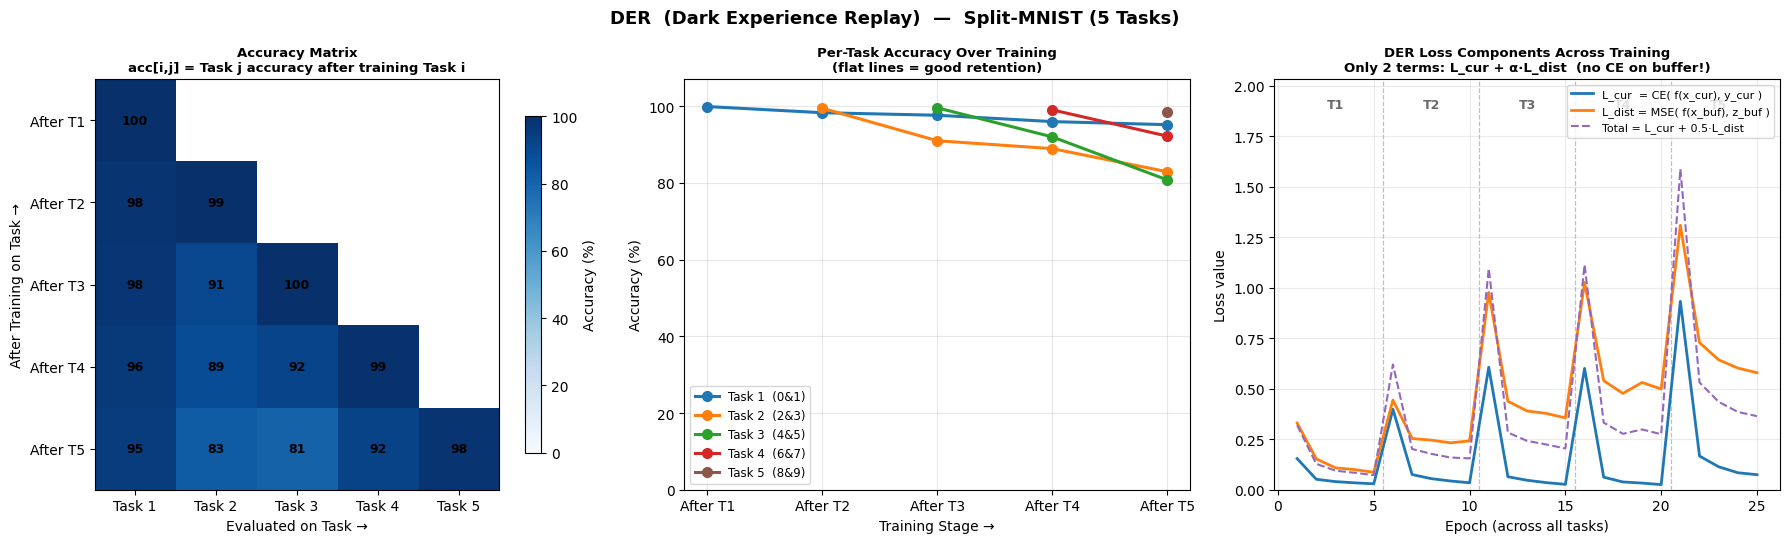


Figure saved → der_results.png

Done! ✓


In [31]:
if __name__ == "__main__":
  print("Loadin Split-MNIST")
  task_loaders = build_split_mnist(data_root="./data", batch_size=128)

  N_EPOCHS = 5
  ALPHA = 0.5

  acc_matrix, loss_history = run_der(
      task_loaders,
      n_epochs=N_EPOCHS,
      lr=1e-3,
      alpha=ALPHA,
      replay_buffer_size=500,
      replay_batch_size=64,
      device=DEVICE
  )

  plot_results(
      acc_matrix, loss_history,
      alpha=ALPHA,
      n_epochs=N_EPOCHS,
      save_path = "der_results.png",
  )
  print("\nDone! ✓")